In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil
import opendatasets as od
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

In [2]:
dataset_url = "https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset"

In [3]:
data_dir = od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


100%|██████████| 50.1k/50.1k [00:00<00:00, 9.02MB/s]

In [4]:
# /.kaggle/kaggle.json
# /home/neuralnine/.kaggle/kaggle.json

In [5]:
data_dir = Path("ibm-hr-analytics-attrition-dataset")
csv_path = data_dir / "WA_Fn-UseC_-HR-Employee-Attrition.csv"

In [6]:
df=pd.read_csv(csv_path)
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
print(f"Shape:{df.shape}")
print("-"*100)
print(df.info())

Shape:(1470, 35)
----------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate    

### Categorical Variables

In [9]:
categorical = []
for col in df.select_dtypes(include='object').columns:
    categorical.append(col)
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print(df[col].value_counts())
    print("="*100)

Column: Attrition
['Yes' 'No']
2
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Column: BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
3
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Column: Department
['Sales' 'Research & Development' 'Human Resources']
3
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
Column: EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
6
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Column: Gender
['Female' 'Male']
2
Gender
Male      882
Female    588
Name: count, dtype: int64
Column: JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare R

### Numerical Variables

In [15]:
numerical = []
for col in df.select_dtypes(include='int').columns:
    numerical.append(col)
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print(df[col].value_counts())
    print("="*100)

Column: Age
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
43
Age
35    78
34    77
36    69
31    69
29    68
32    61
30    60
33    58
38    58
40    57
37    50
27    48
28    48
42    46
39    42
45    41
41    40
26    39
44    33
46    33
43    32
50    30
24    26
25    26
49    24
47    24
55    22
53    19
48    19
51    19
54    18
52    18
22    16
56    14
23    14
58    14
21    13
20    11
59    10
19     9
18     8
60     5
57     4
Name: count, dtype: int64
Column: DailyRate
[1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  5

In [16]:
df.drop(["Over18", "EmployeeCount", "EmployeeNumber", "StandardHours"], axis='columns', inplace=True)
for col in ["EmployeeCount", "EmployeeNumber", "StandardHours"]:
    numerical.remove(col)

### Data Exploration

Is to understand the association individuals jobs and to see what is causing them to leave their job

In [17]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


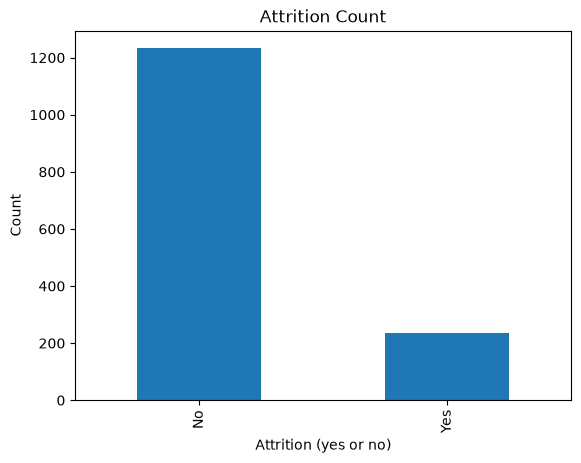

In [18]:
Attrition_count = df["Attrition"].value_counts().plot(kind="bar")

plt.title("Attrition Count")
plt.xlabel("Attrition (yes or no)")
plt.ylabel("Count")
plt.show()

Seeing what may contribute to attrition (NOTE: UNBALANCED DATA SET)

In [19]:
df_copy = df.copy()
label = LabelEncoder()
df_copy["Attrition"] = label.fit_transform(df_copy["Attrition"])

attrition_yes_df = df_copy[df_copy["Attrition"] == 1]
attrition_no_df = df_copy[df_copy["Attrition"] == 0]

### HEAT MAP FOR ATTRITION YES

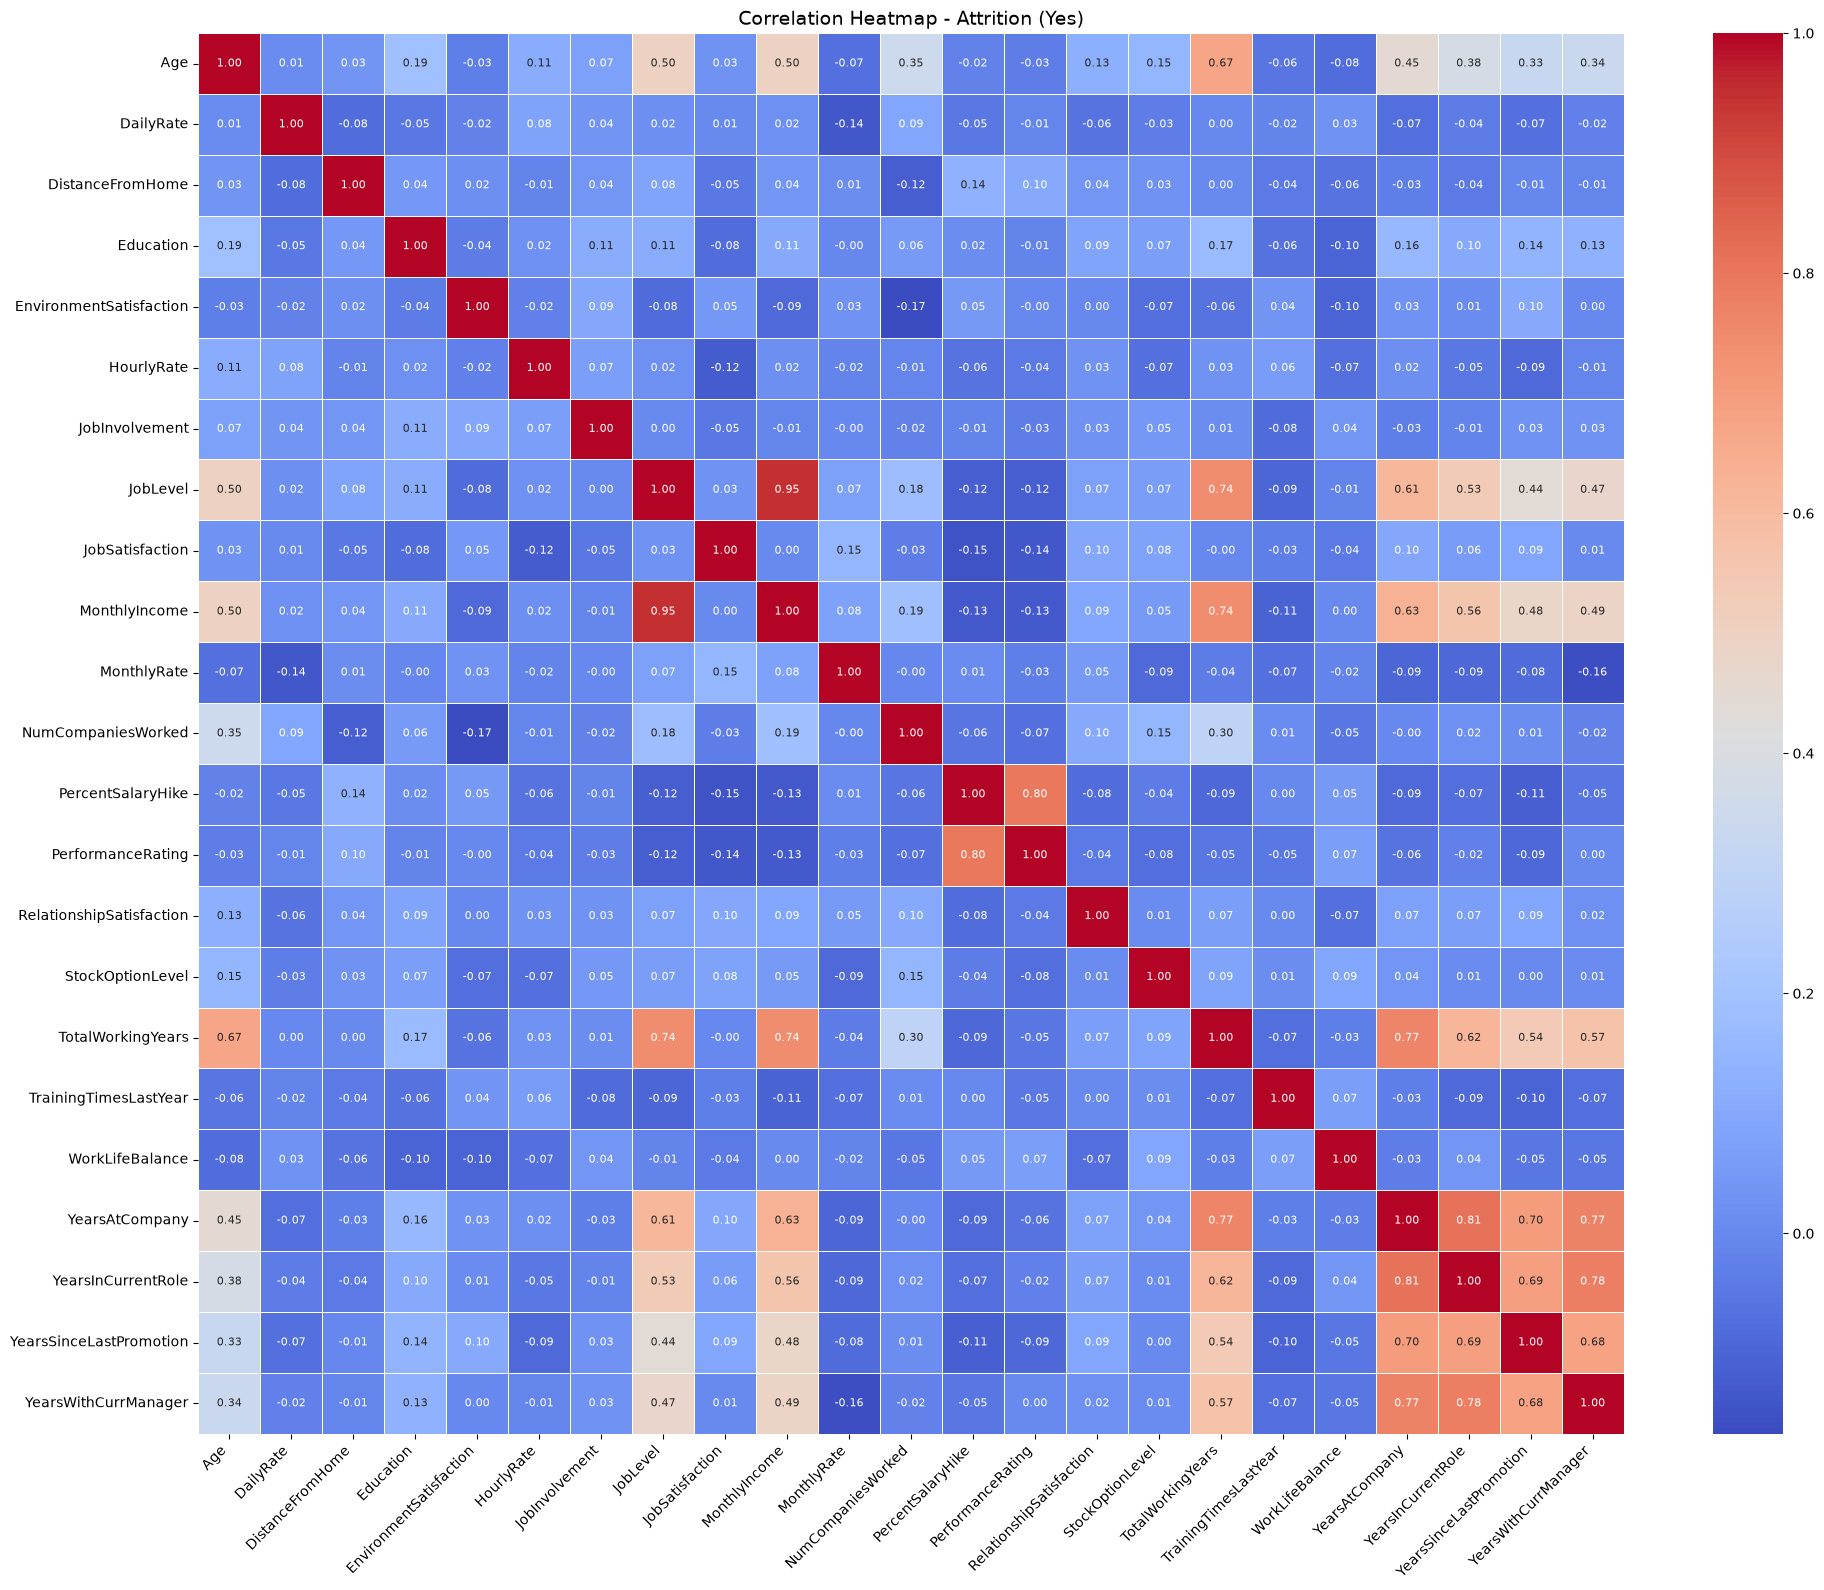

In [20]:
corr_matrix = attrition_yes_df[numerical].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size": 8}  
)
plt.title('Correlation Heatmap - Attrition (Yes)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Heat Map for ATTRITION NO

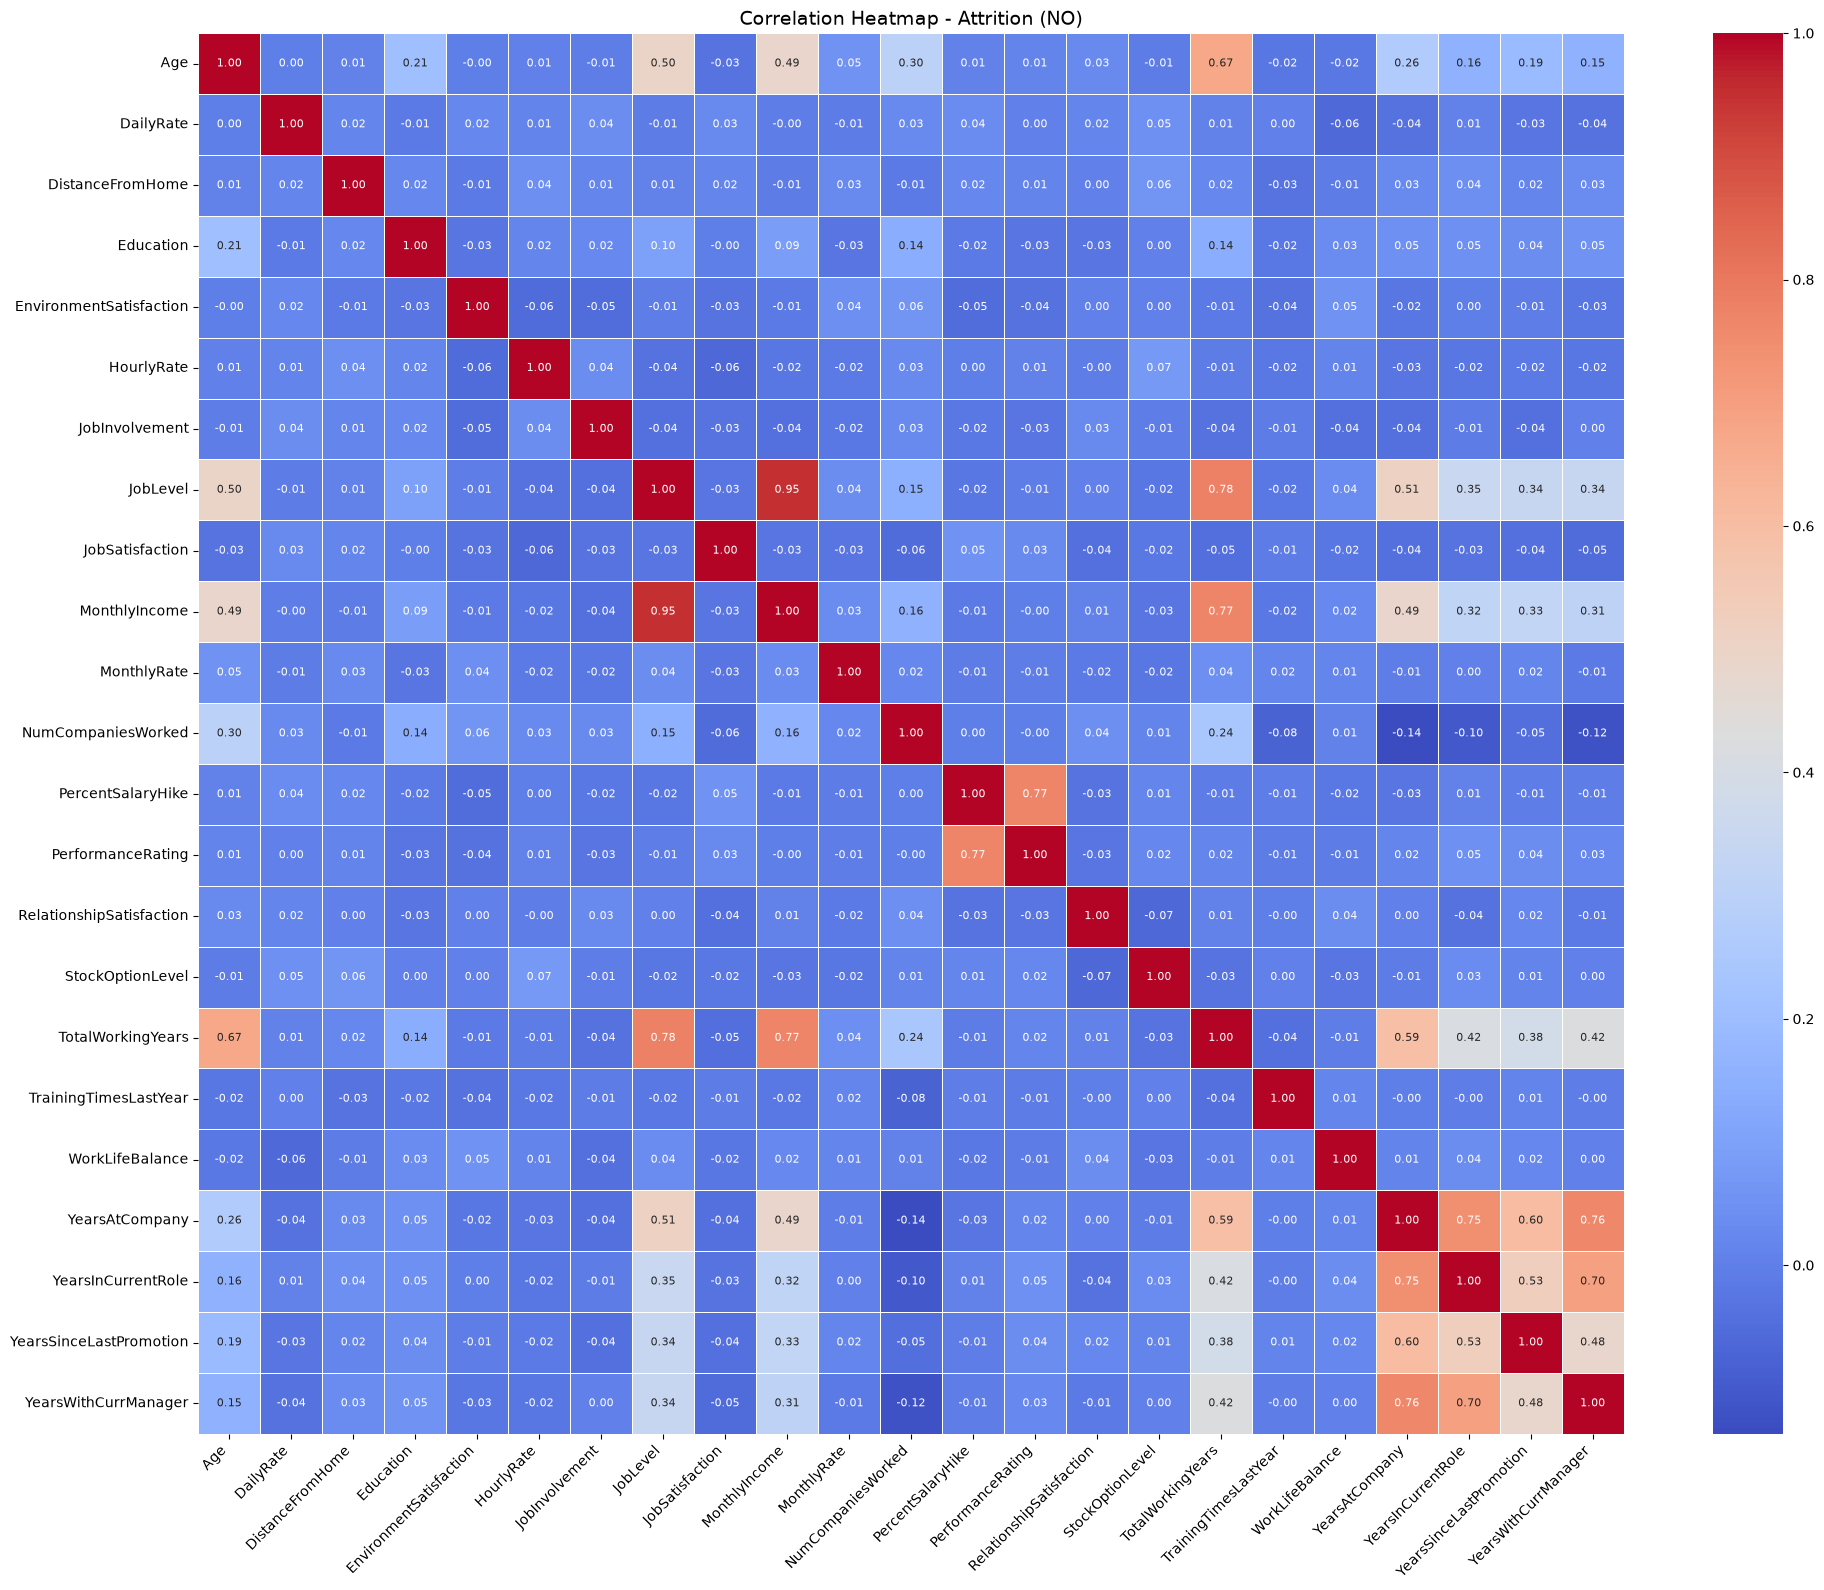

In [21]:
corr_matrix = attrition_no_df[numerical].corr()

plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix,
           annot=True,
           fmt=".2f",
           cmap = "coolwarm",
           linewidths=0.5, 
           annot_kws={"size": 8}
           )
plt.title("Correlation Heatmap - Attrition (NO)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
def plot_attrition_comparison(df_yes, df_no):
    categorical_cols = df_yes.select_dtypes(include='object').columns
    categorical_cols = [col for col in categorical_cols if col != 'Attrition']
    
    for col in categorical_cols:
        counts_yes = df_yes[col].value_counts()
        counts_no = df_no[col].value_counts()
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        axes[0].barh(counts_yes.index, counts_yes.values, color='indianred')
        axes[0].set_title(f'{col} - Attrition: Yes')
        axes[0].invert_yaxis()  # keeps highest count at top
        
        axes[1].barh(counts_no.index, counts_no.values, color='steelblue')
        axes[1].set_title(f'{col} - Attrition: No')
        axes[1].invert_yaxis()
        
        plt.tight_layout()
        plt.show()

C:\Users\Flami\AppData\Local\Temp\ipykernel_69112\2784541769.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_yes.select_dtypes(include='object').columns


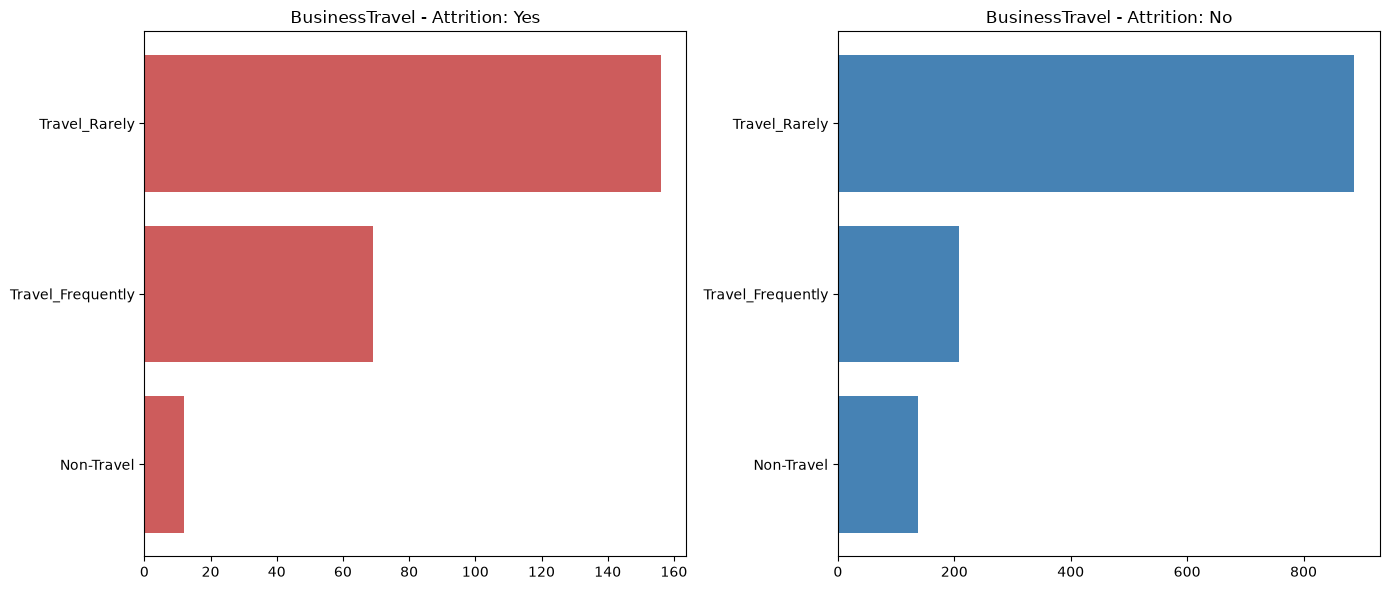

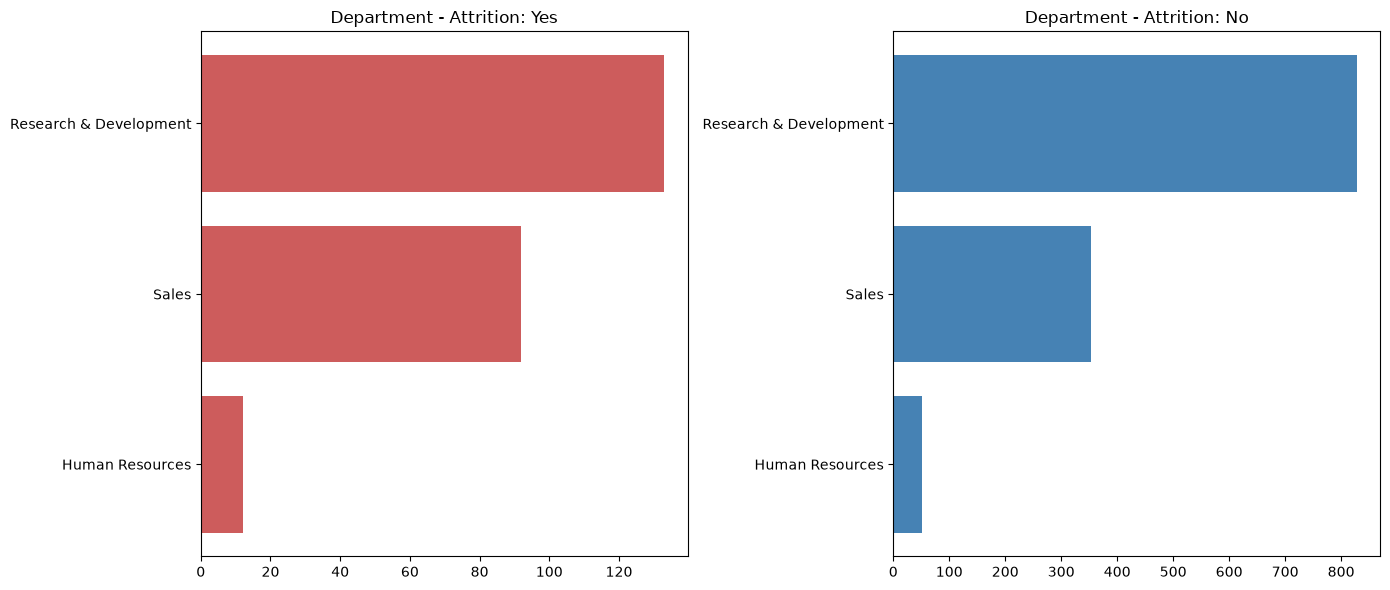

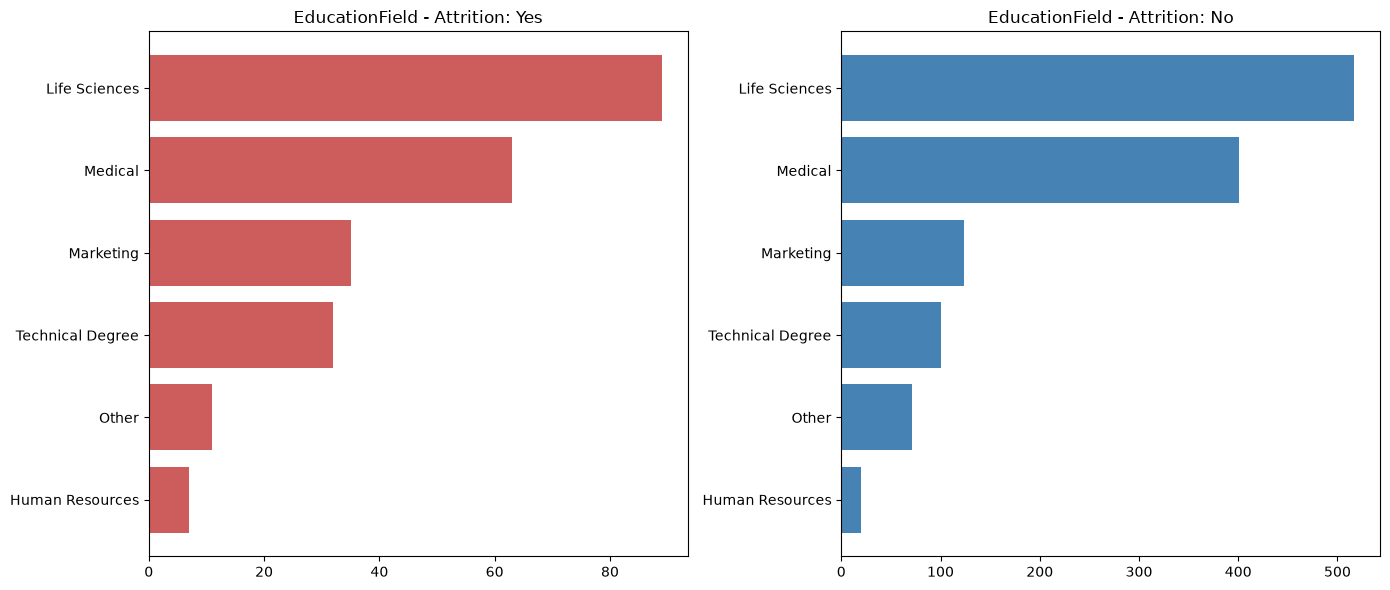

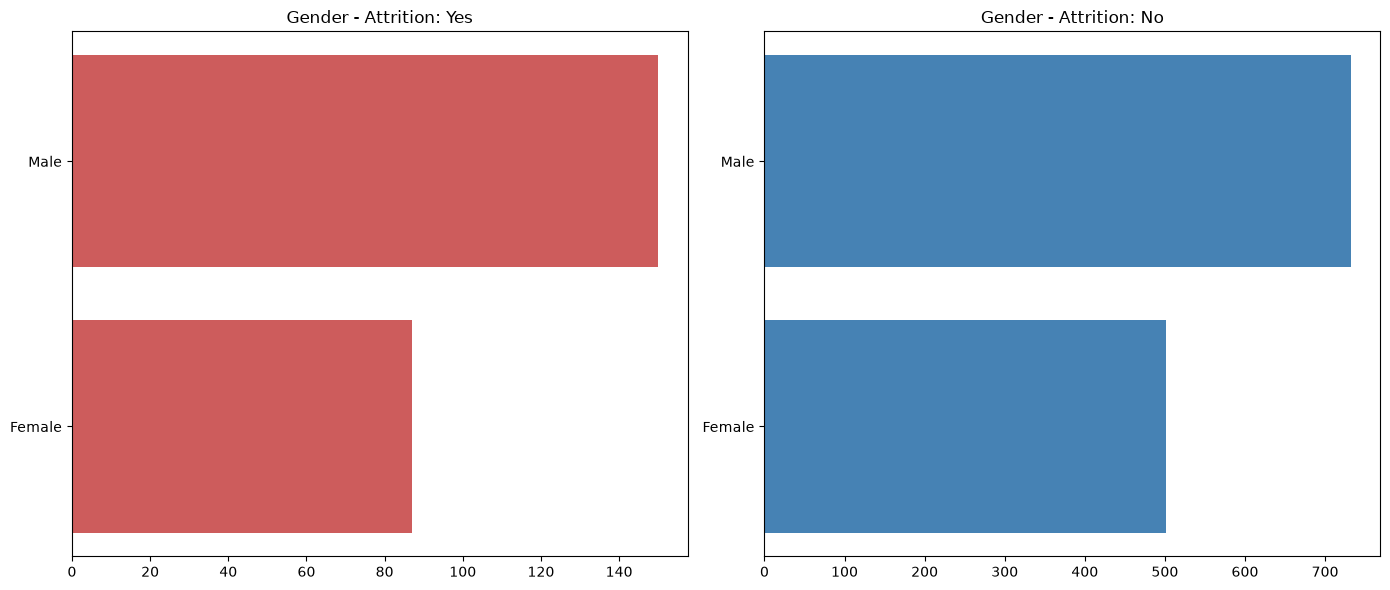

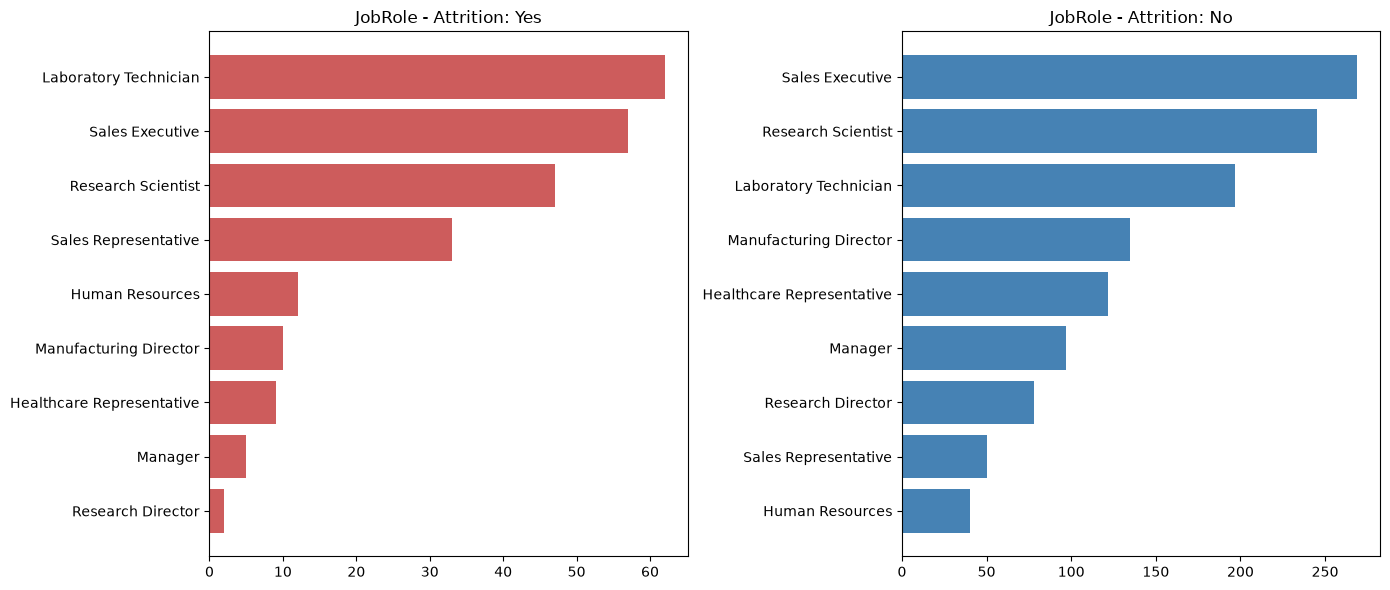

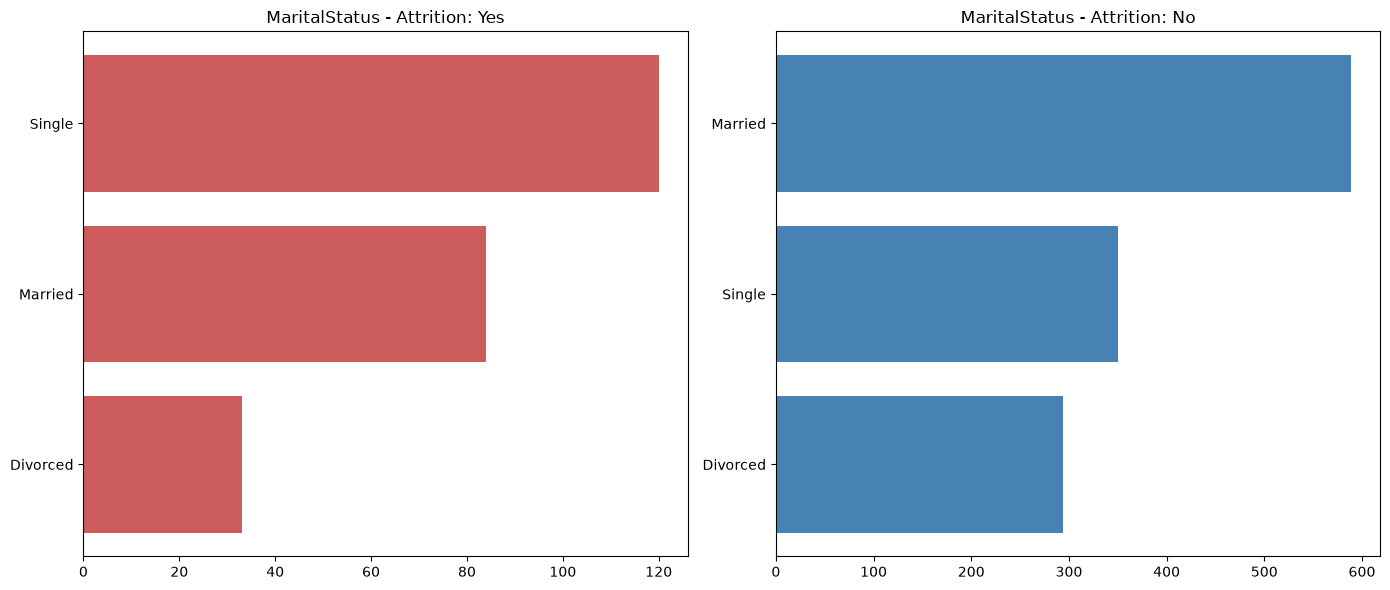

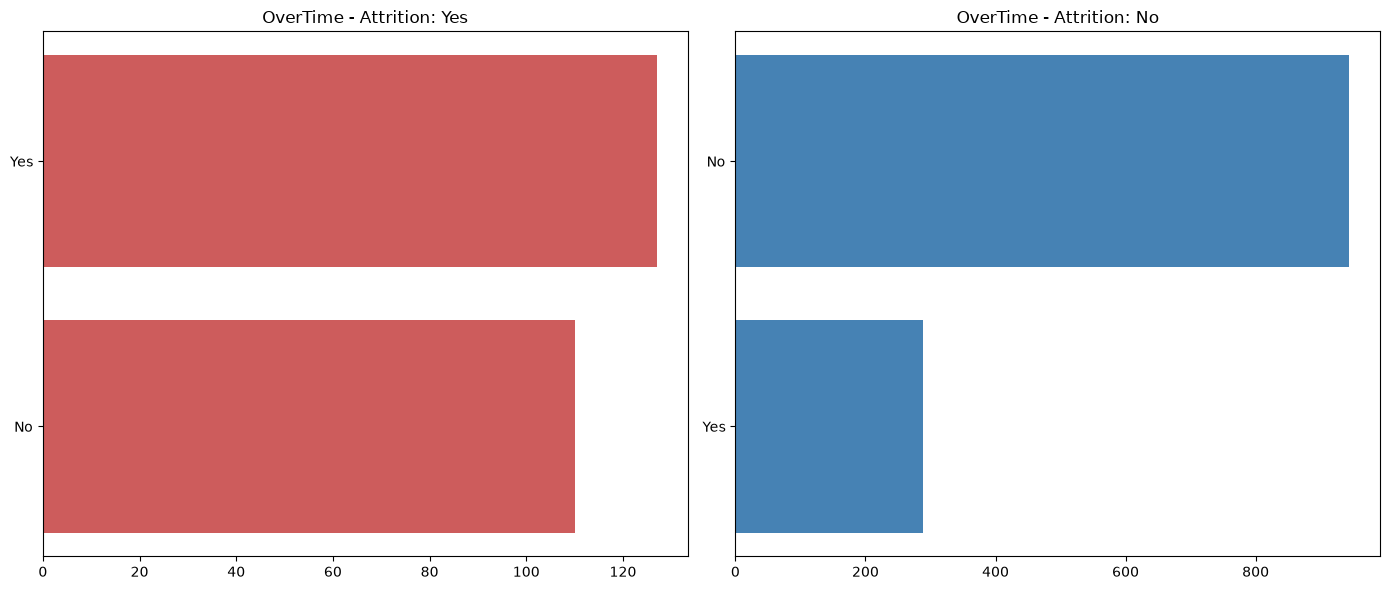

In [25]:
plot_attrition_comparison(attrition_yes_df, attrition_no_df)

# What we understand from our analysis

From the Anlaysis runned through both numerical and categorical features of Attritions (YES & NO), there are indicators of differences between why an individual would leave IBM. 
Examples inlcude: 

- Overtime, Job Role, Pay, Years with the company, etc.
These are high indication of either the pay did not satisfy an individual or they seek for new or higher positions else where.

# Usage of classification Machine Learning:

To help us further understand our findings and really point out reasons for the attritions happening in the company, we can run classification models to really see what features stand out as to why and individual would leave the compnay. 

### Data Processing

In [44]:
dummy_features = [column for column in df.drop("Attrition", axis=1).columns if df[column].nunique() < 20]
data_dummy = pd.get_dummies(df, columns=dummy_features, drop_first=True, dtype='uint8')
data_dummy.info()
data_dummy.head()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Columns: 136 entries, Age to YearsWithCurrManager_17
dtypes: int64(8), str(1), uint8(127)
memory usage: 285.8 KB


,Age,Attrition,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,TotalWorkingYears,YearsAtCompany,BusinessTravel_Travel_Frequently,...,YearsWithCurrManager_8,YearsWithCurrManager_9,YearsWithCurrManager_10,YearsWithCurrManager_11,YearsWithCurrManager_12,YearsWithCurrManager_13,YearsWithCurrManager_14,YearsWithCurrManager_15,YearsWithCurrManager_16,YearsWithCurrManager_17
0,41,Yes,1102,1,94,5993,19479,8,6,0,...,0,0,0,0,0,0,0,0,0,0
1,49,No,279,8,61,5130,24907,10,10,1,...,0,0,0,0,0,0,0,0,0,0
2,37,Yes,1373,2,92,2090,2396,7,0,0,...,0,0,0,0,0,0,0,0,0,0
3,33,No,1392,3,56,2909,23159,8,8,1,...,0,0,0,0,0,0,0,0,0,0
4,27,No,591,2,40,3468,16632,6,2,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
data_dummy = data_dummy.T.drop_duplicates() #duplicated features 
data_dummy = data_dummy.T
data_dummy.drop_duplicates(inplace=True)

<Axes: >

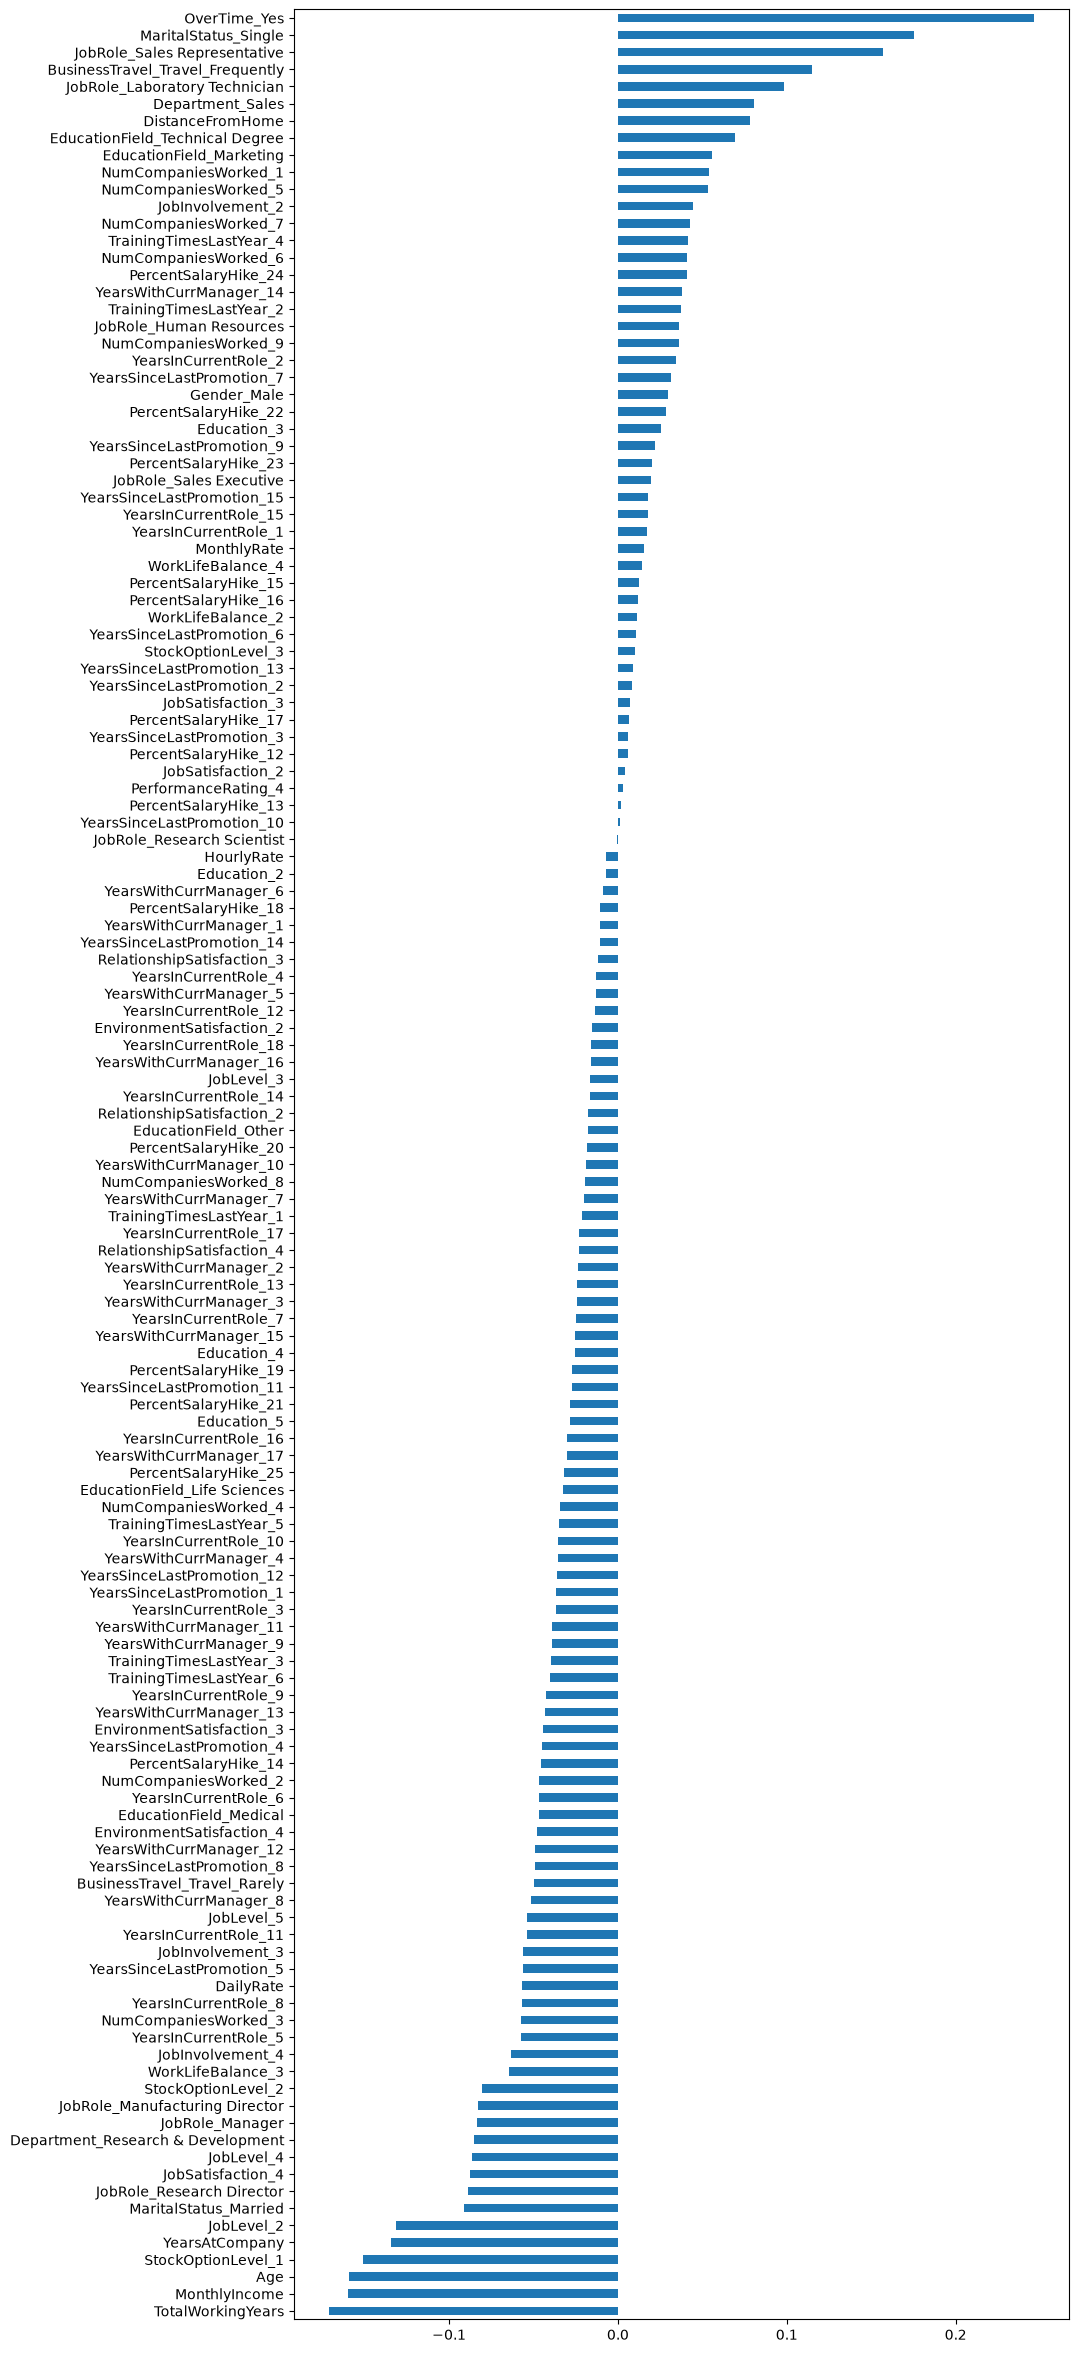

In [51]:
data_dummy['Attrition'] = data_dummy['Attrition'].map({'Yes': 1, 'No': 0})
data_dummy.drop('Attrition', axis=1).corrwith(data_dummy.Attrition).sort_values().plot(kind='barh', figsize=(10, 30))

In [54]:
from sklearn.model_selection import train_test_split, GridSearchCV  
from sklearn.preprocessing import StandardScaler

X = data_dummy.drop("Attrition", axis=1)
y = data_dummy.Attrition

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)   
X_test_std = scaler.transform(X_test)         
X_std = scaler.transform(X)                  

In [121]:
def feature_imp(df, model):
    fi = pd.DataFrame()
    fi["feature"] = df.columns
    fi["importance"] = model.feature_importances_   # ← must be "importances_" with an S
    return fi.sort_values(by="importance", ascending=False)

## Our Hypothesis
### Percentage of what we believe will stay

In [108]:
#OUR ASSUMPTION OR HYPOTHESIS
float(y_test.value_counts()[0] / y_test.shape[0])

0.8390022675736961

In [109]:
stay = (y_train.value_counts()[0] / y_train.shape[0])
leave = (y_train.value_counts()[1] /  y_train.shape[0])

print("===============TRAIN=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

stay = (y_test.value_counts()[0] / y_test.shape[0])
leave = (y_test.value_counts()[0] / y_test.shape[0])

print("===============TRAIN=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

===============TRAIN=================
Staying Rate: 83.87%
Leaving Rate: 16.13%
===============TRAIN=================
Staying Rate: 83.90%
Leaving Rate: 83.90%


# EVALUATION METRIC

In [110]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score

In [111]:
def evaluation(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    print("TRAINIG RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")

    print("TESTING RESULTS: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"CLASSIFICATION REPORT:\n{clf_report}")
    

# Logistic Regression

In [112]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(solver="liblinear", penalty='l1')
lr_clf.fit(X_train_std, y_train)

evaluation(lr_clf, X_train_std, X_test_std, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[849  14]
 [ 59 107]]
ACCURACY SCORE:
0.9291
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.935022    0.884298  0.929057     0.909660      0.926839
recall       0.983778    0.644578  0.929057     0.814178      0.929057
f1-score     0.958780    0.745645  0.929057     0.852212      0.924397
support    863.000000  166.000000  0.929057  1029.000000   1029.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[348  22]
 [ 43  28]]
ACCURACY SCORE:
0.8526
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.890026   0.560000  0.852608    0.725013      0.836892
recall       0.940541   0.394366  0.852608    0.667453      0.852608
f1-score     0.914586   0.462810  0.852608    0.688698      0.841851
support    370.000000  71.000000  0.852608  441.000000    441.000000


C:\Users\Flami\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Flami\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


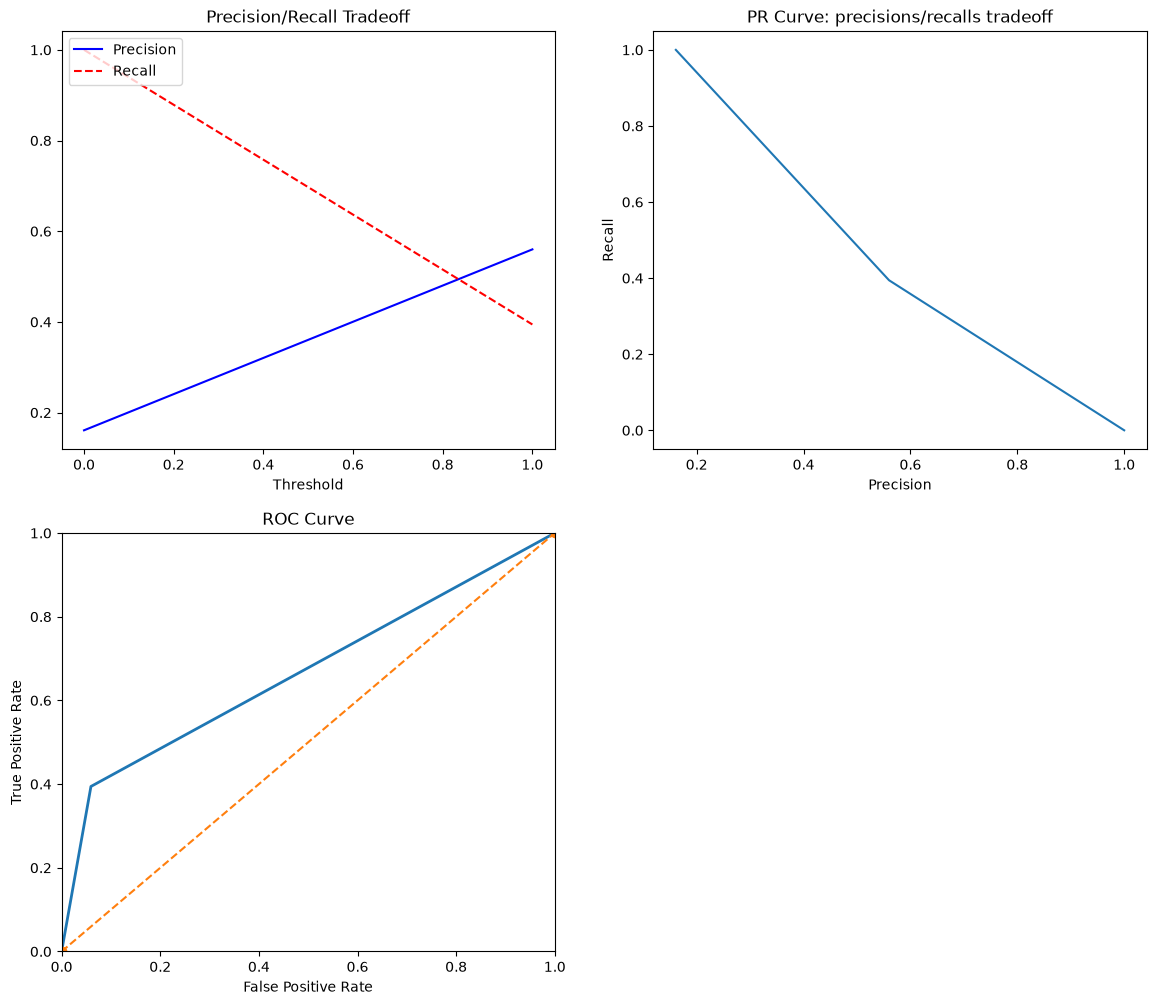

In [124]:
from sklearn.metrics import precision_recall_curve, roc_curve

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b-", label="Precision")
    plt.plot(thresholds, recalls[:-1], "r--", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.title("Precision/Recall Tradeoff")
    

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], "o--")
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    
    
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_clf.predict(X_test_std))
plt.figure(figsize=(14, 25))
plt.subplot(4, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

plt.subplot(4, 2, 2)
plt.plot(precisions, recalls)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("PR Curve: precisions/recalls tradeoff");

plt.subplot(4, 2, 3)
fpr, tpr, thresholds = roc_curve(y_test, lr_clf.predict(X_test_std))
plot_roc_curve(fpr, tpr)

In [125]:
scores_dict = {
    "Logistic Regression": {
        'Train': roc_auc_score(y_train, lr_clf.predict(X_train)),
        'Test': roc_auc_score(y_test, lr_clf.predict(X_test)),
    },
}

C:\Users\Flami\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Flami\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


# RandomForestClassifier

In [126]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, bootstrap=False)
rf_clf.fit(X_train_std, y_train)

evaluation(rf_clf, X_train_std, X_test_std, y_train, y_test)

TRAINIG RESULTS: 
CONFUSION MATRIX:
[[863   0]
 [  0 166]]
ACCURACY SCORE:
1.0000
CLASSIFICATION REPORT:
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    863.0  166.0       1.0     1029.0        1029.0
TESTING RESULTS: 
CONFUSION MATRIX:
[[357  13]
 [ 62   9]]
ACCURACY SCORE:
0.8299
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.852029   0.409091  0.829932    0.630560      0.780717
recall       0.964865   0.126761  0.829932    0.545813      0.829932
f1-score     0.904943   0.193548  0.829932    0.549246      0.790410
support    370.000000  71.000000  0.829932  441.000000    441.000000


In [127]:
# GRID SEARCHING the RandomForest trying to see which one works best

param_grid = dict(
    n_estimators=[100, 500, 900],
    max_features=['sqrt', 'log2'],
    max_depth=[2, 3, 5, 10, 15, None],
    min_samples_split=[2, 5, 10],
    min_samples_leaf=[1, 2, 4],
    bootstrap=[True, False]
)

rf_clf = RandomForestClassifier(random_state=42)

search = GridSearchCV(rf_clf, param_grid=param_grid, scoring='roc_auc', cv=5, verbose=1, n_jobs=-1)
search.fit(X_train, y_train)

rf_clf = RandomForestClassifier(**search.best_params_, random_state=42)
rf_clf.fit(X_train, y_train)

evaluation(rf_clf, X_train, X_test, y_train, y_test)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
TRAINIG RESULTS: 
CONFUSION MATRIX:
[[863   0]
 [ 15 151]]
ACCURACY SCORE:
0.9854
CLASSIFICATION REPORT:
                    0           1  accuracy    macro avg  weighted avg
precision    0.982916    1.000000  0.985423     0.991458      0.985672
recall       1.000000    0.909639  0.985423     0.954819      0.985423
f1-score     0.991384    0.952681  0.985423     0.972033      0.985141
support    863.000000  166.000000  0.985423  1029.000000   1029.000000
TESTING RESULTS: 
CONFUSION MATRIX:
[[360  10]
 [ 63   8]]
ACCURACY SCORE:
0.8345
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.851064   0.444444  0.834467    0.647754      0.785599
recall       0.972973   0.112676  0.834467    0.542825      0.834467
f1-score     0.907945   0.179775  0.834467    0.543860      0.790711
support    370.000000  71.000000  0.834467  441.000000    441.000000


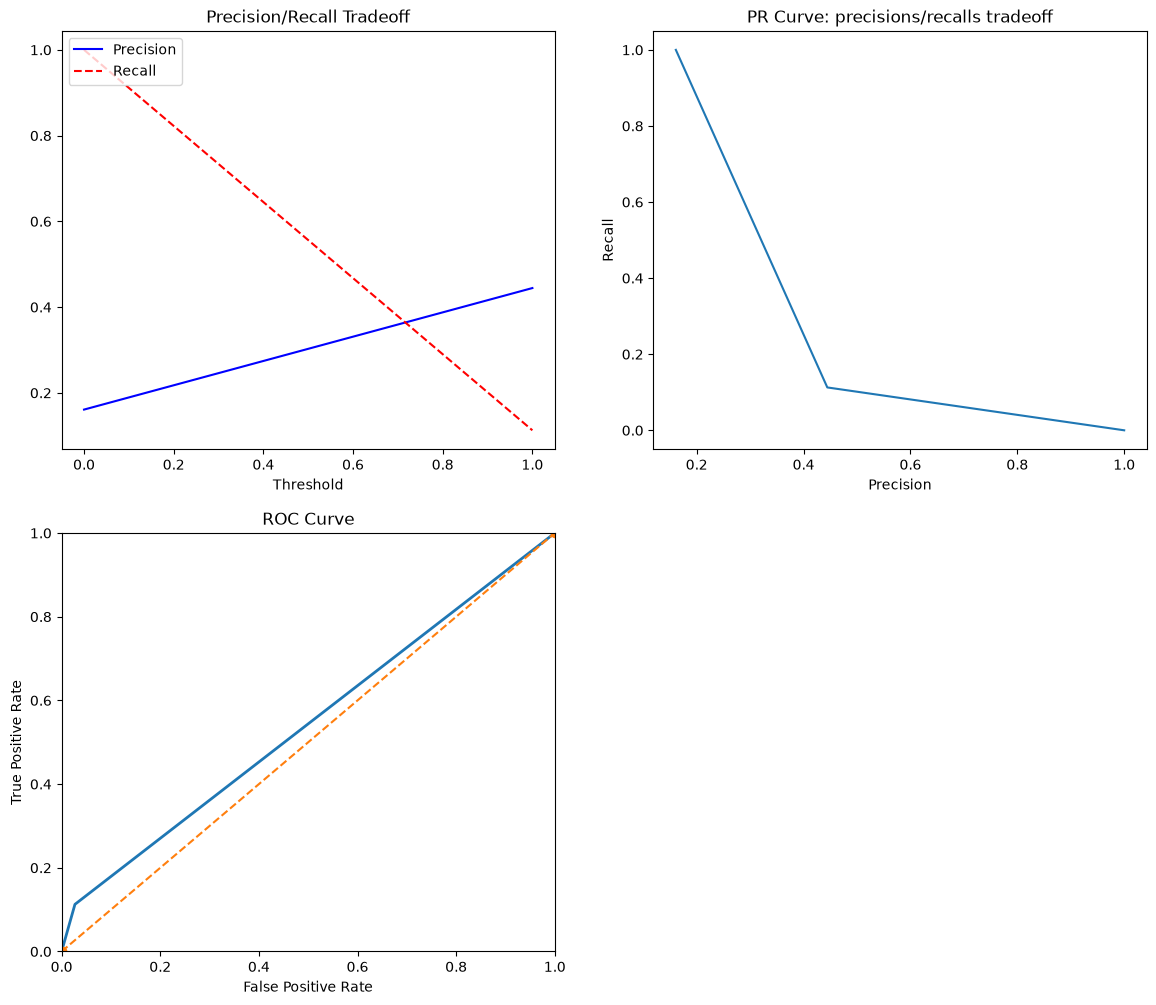

In [128]:
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_clf.predict(X_test))
plt.figure(figsize=(14, 25))
plt.subplot(4, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

plt.subplot(4, 2, 2)
plt.plot(precisions, recalls)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("PR Curve: precisions/recalls tradeoff");

plt.subplot(4, 2, 3)
fpr, tpr, thresholds = roc_curve(y_test, rf_clf.predict(X_test))
plot_roc_curve(fpr, tpr)

In [129]:
scores_dict["Random Forest"] = {
    "Train" : roc_auc_score(y_train, rf_clf.predict(X_train)),
    "Test" : roc_auc_score(y_test, rf_clf.predict(X_test))
}

Text(0.5, 1.0, 'Feature Importance based off of the Random Forest')

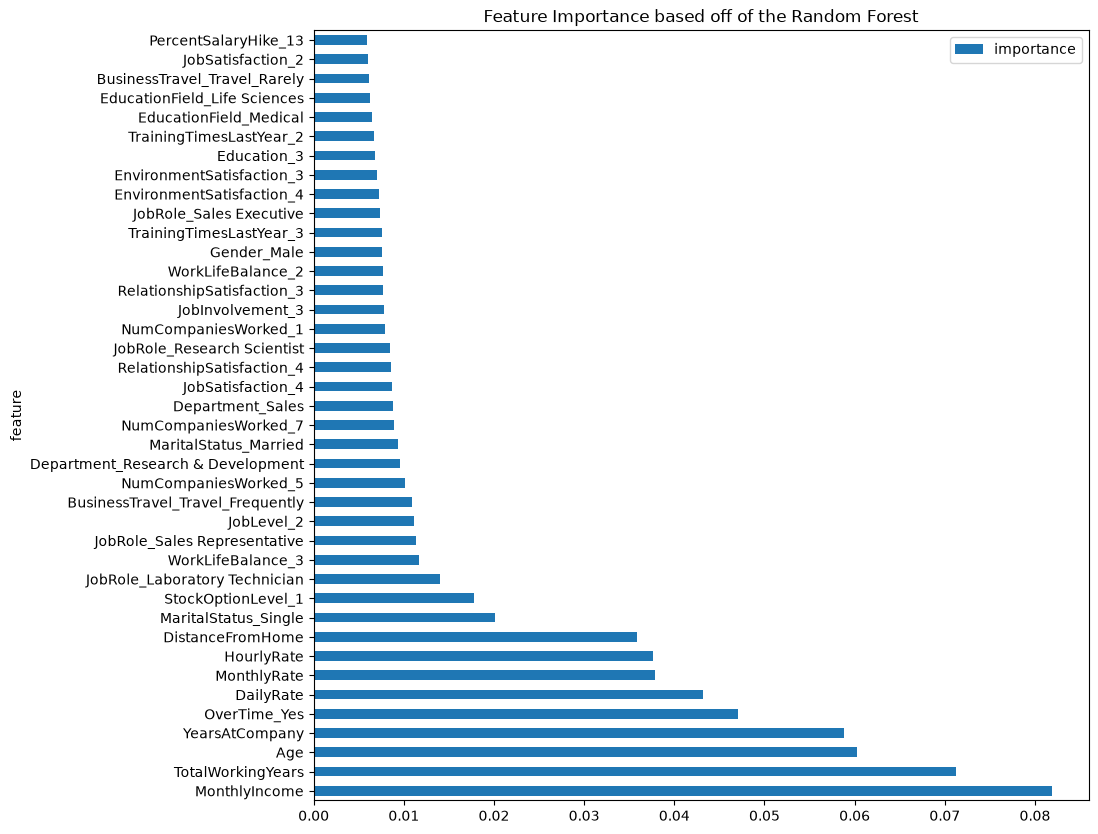

In [130]:
df = feature_imp(X, rf_clf)[:40]
df.set_index("feature", inplace=True)
df.plot(kind="barh", figsize=(10,10))
plt.title("Feature Importance based off of the Random Forest")